In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression, LinearRegression

def generate_research_data(n=2000, overlap_strength=1.0, base_seed=12345):
    # Deterministic seed per overlap strength
    seed = base_seed + int(1000 * overlap_strength)
    rng = np.random.default_rng(seed)

    # x is centered at 2 to break symmetry and expose OLS bias
    x = rng.normal(2, 1, n)

    # Treatment assignment (Propensity)
    logits = overlap_strength * x + rng.normal(0, 0.5, n)
    prob_t = 1 / (1 + np.exp(-logits))
    t = rng.binomial(1, prob_t)

    # Outcome with non-linearity (x^2)
    # True ATE = 5.0
    y = (
        10
        + 5.0 * t
        + 3.0 * x
        + 1.5 * x**2
        + rng.normal(0, 1, n)
    )

    return pd.DataFrame({"x": x, "t": t, "y": y})


In [17]:
def get_all_estimates(df):
    # 1. Propensity Score
    lr = LogisticRegression(penalty=None).fit(df[['x']], df['t'])
    df['ps'] = np.clip(lr.predict_proba(df[['x']])[:, 1], 0.001, 0.999)
    
    # 2. Outcome Models
    m1 = LinearRegression().fit(df[df.t==1][['x']], df[df.t==1]['y'])
    m0 = LinearRegression().fit(df[df.t==0][['x']], df[df.t==0]['y'])
    df['mu1'], df['mu0'] = m1.predict(df[['x']]), m0.predict(df[['x']])
    
    # --- OLS ---
    ols_ate = smf.ols('y ~ t + x', data=df).fit().params['t']
    
    # --- IPTW (Hajek) ---
    w1, w0 = df.t/df.ps, (1-df.t)/(1-df.ps)
    iptw_ate = (df.y*w1).sum()/w1.sum() - (df.y*w0).sum()/w0.sum()
    
    # --- AIPW (Doubly Robust) ---
    dr_ate = ((df.mu1 - df.mu0) + (df.t*(df.y-df.mu1)/df.ps) - ((1-df.t)*(df.y-df.mu0)/(1-df.ps))).mean()
    
    # --- Meta-Learners ---
    # S-Learner
    s_mod = LinearRegression().fit(df[['t', 'x']], df['y'])
    s_ate = (s_mod.predict(df.assign(t=1)[['t', 'x']]) - s_mod.predict(df.assign(t=0)[['t', 'x']])).mean()
    
    # T-Learner
    t_ate = (df.mu1 - df.mu0).mean()
    
    # X-Learner
    d1 = df[df.t==1]['y'] - m0.predict(df[df.t==1][['x']])
    d0 = m1.predict(df[df.t==0][['x']]) - df[df.t==0]['y']
    mx1, mx0 = LinearRegression().fit(df[df.t==1][['x']], d1), LinearRegression().fit(df[df.t==0][['x']], d0)
    x_ate = (df.ps * mx0.predict(df[['x']]) + (1 - df.ps) * mx1.predict(df[['x']])).mean()

    return {'OLS': ols_ate, 'IPTW': iptw_ate, 'AIPW': dr_ate, 
            'S-Learner': s_ate, 'T-Learner': t_ate, 'X-Learner': x_ate}

In [18]:
df_high = generate_research_data(n=2000, overlap_strength=1.0)
print(get_all_estimates(df_high))

{'OLS': 4.551636589995505, 'IPTW': 5.670179602525124, 'AIPW': 5.349977431649366, 'S-Learner': 4.5516365899955105, 'T-Learner': 5.898596250056784, 'X-Learner': 5.898596250056782}


In [19]:
df_high = generate_research_data(n=2000, overlap_strength=4.50)
print(get_all_estimates(df_high))

{'OLS': -2.0858162280098553, 'IPTW': 10.611362538645157, 'AIPW': 10.181280706028879, 'S-Learner': -2.085816228009866, 'T-Learner': 13.222092717133044, 'X-Learner': 13.222092717133044}


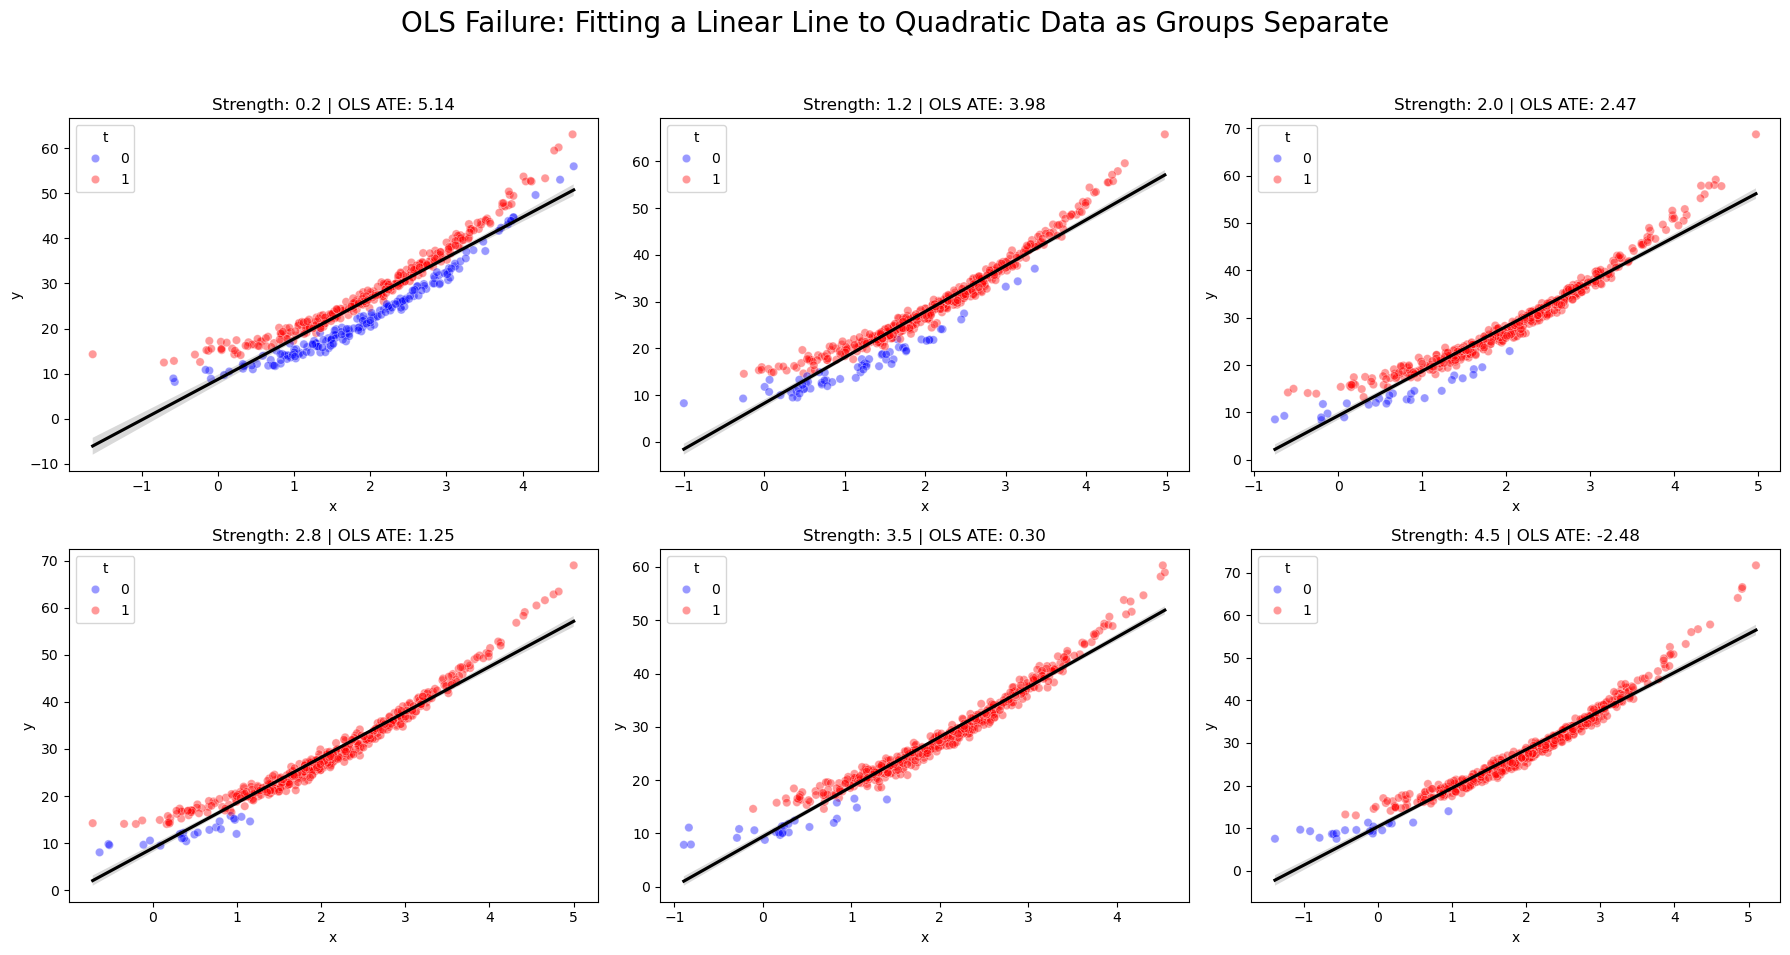

In [20]:
strengths = [0.2, 1.2, 2.0, 2.8, 3.5, 4.5]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    df = generate_research_data(n=500, overlap_strength=s)
    ate_val = smf.ols('y ~ t + x', data=df).fit().params['t']
    
    sns.scatterplot(data=df, x='x', y='y', hue='t', ax=axes[i], palette=['blue', 'red'], alpha=0.4)
    sns.regplot(data=df, x='x', y='y', scatter=False, color='black', ax=axes[i])
    axes[i].set_title(f"Strength: {s} | OLS ATE: {ate_val:.2f}")

plt.suptitle("OLS Failure: Fitting a Linear Line to Quadratic Data as Groups Separate", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

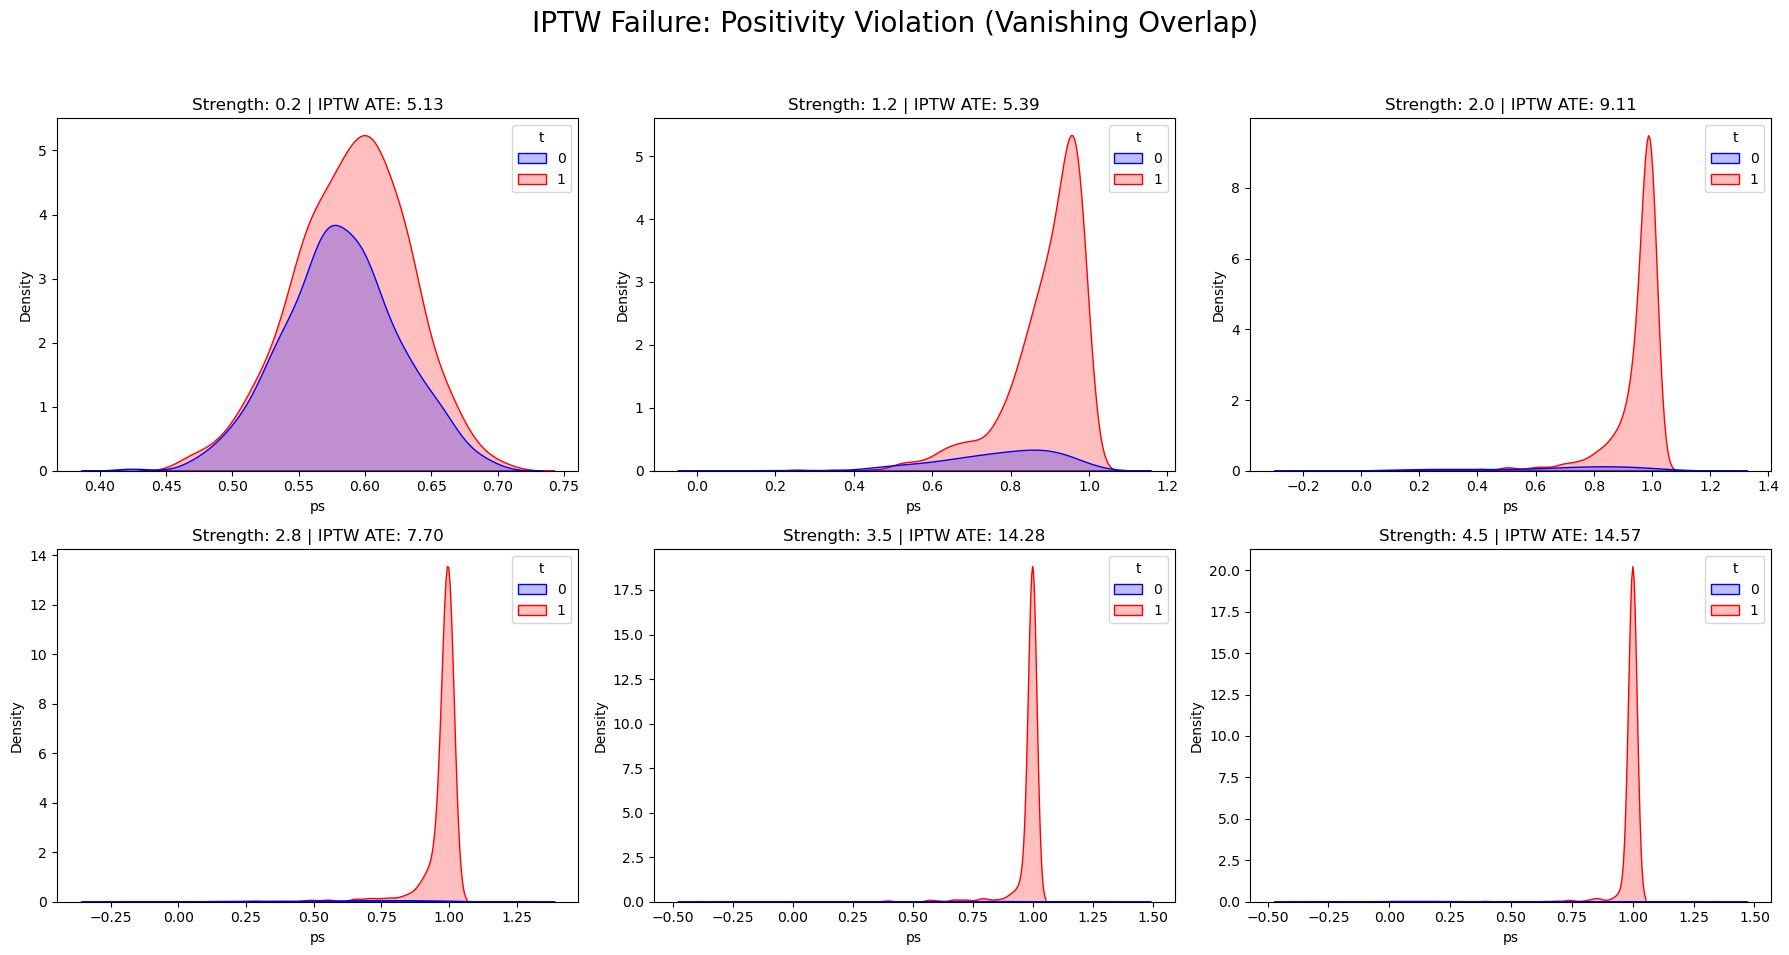

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, s in enumerate(strengths):
    df = generate_research_data(n=1000, overlap_strength=s)
    lr = LogisticRegression(penalty=None).fit(df[['x']], df['t'])
    df['ps'] = lr.predict_proba(df[['x']])[:, 1]
    
    sns.kdeplot(data=df, x='ps', hue='t', fill=True, ax=axes.flatten()[i], palette=['blue', 'red'])
    # Calculate IPTW ATE for title
    w1, w0 = df['t']/df['ps'], (1-df['t'])/(1-df['ps'])
    iptw_val = (df['y']*w1).sum()/w1.sum() - (df['y']*w0).sum()/w0.sum()
    axes.flatten()[i].set_title(f"Strength: {s} | IPTW ATE: {iptw_val:.2f}")

plt.suptitle("IPTW Failure: Positivity Violation (Vanishing Overlap)", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

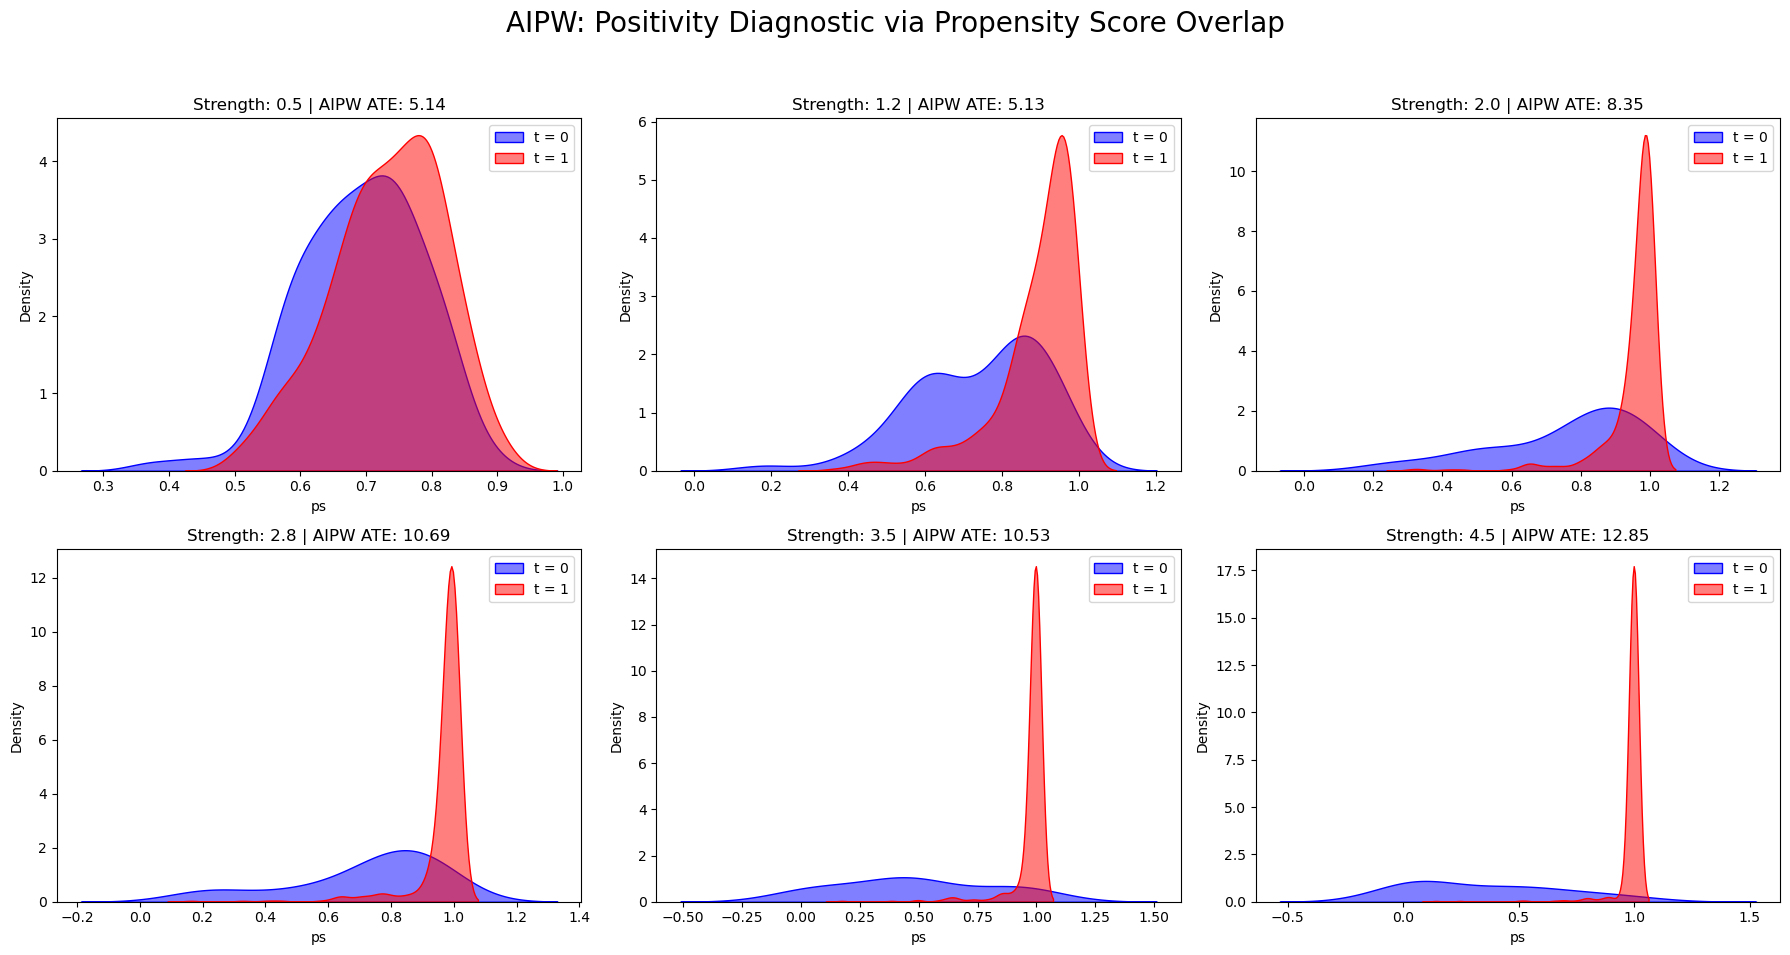

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    df = generate_research_data(n=500, overlap_strength=s)

    # --- Propensity model ---
    lr = LogisticRegression(penalty=None).fit(df[['x']], df['t'])
    ps = lr.predict_proba(df[['x']])[:, 1]
    ps_clip = np.clip(ps, 0.001, 0.999)

    # --- Outcome models ---
    m1 = LinearRegression().fit(df[df.t==1][['x']], df[df.t==1]['y'])
    m0 = LinearRegression().fit(df[df.t==0][['x']], df[df.t==0]['y'])

    mu1 = m1.predict(df[['x']])
    mu0 = m0.predict(df[['x']])

    # --- AIPW estimator ---
    aipw_ate = (
        (mu1 - mu0)
        + df.t * (df.y - mu1) / ps_clip
        - (1 - df.t) * (df.y - mu0) / (1 - ps_clip)
    ).mean()

    # --- KDE of propensity scores (diagnostic) ---
    df_plot = df.copy()
    df_plot["ps"] = ps

    sns.kdeplot(
        data=df_plot[df_plot.t == 0],
        x="ps",
        fill=True,
        alpha=0.5,
        label="t = 0",
        color="blue",
        ax=axes[i]
    )

    sns.kdeplot(
        data=df_plot[df_plot.t == 1],
        x="ps",
        fill=True,
        alpha=0.5,
        label="t = 1",
        color="red",
        ax=axes[i]
    )

    axes[i].set_title(f"Strength: {s} | AIPW ATE: {aipw_ate:.2f}")
    axes[i].set_xlabel("ps")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle(
    "AIPW: Positivity Diagnostic via Propensity Score Overlap",
    fontsize=20
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HIMADRI CHATTERJEE\AppData\Local\Temp\ipykernel_24996\3229636000.py:17: SyntaxWarning: invalid escape sequence '\m'
  axes[i].plot(x_range, m1.predict(x_range), color='red', label='$\mu_1$ (Treated Fit)')
C:\Users\HIMADRI CHATTERJEE\AppData\Local\Temp\ipykernel_24996\3229636000.py:18: SyntaxWarning: invalid escape sequence '\m'
  axes[i].plot(x_range, m0.predict(x_range), color='blue', label='$\mu_0$ (Control Fit)')
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\

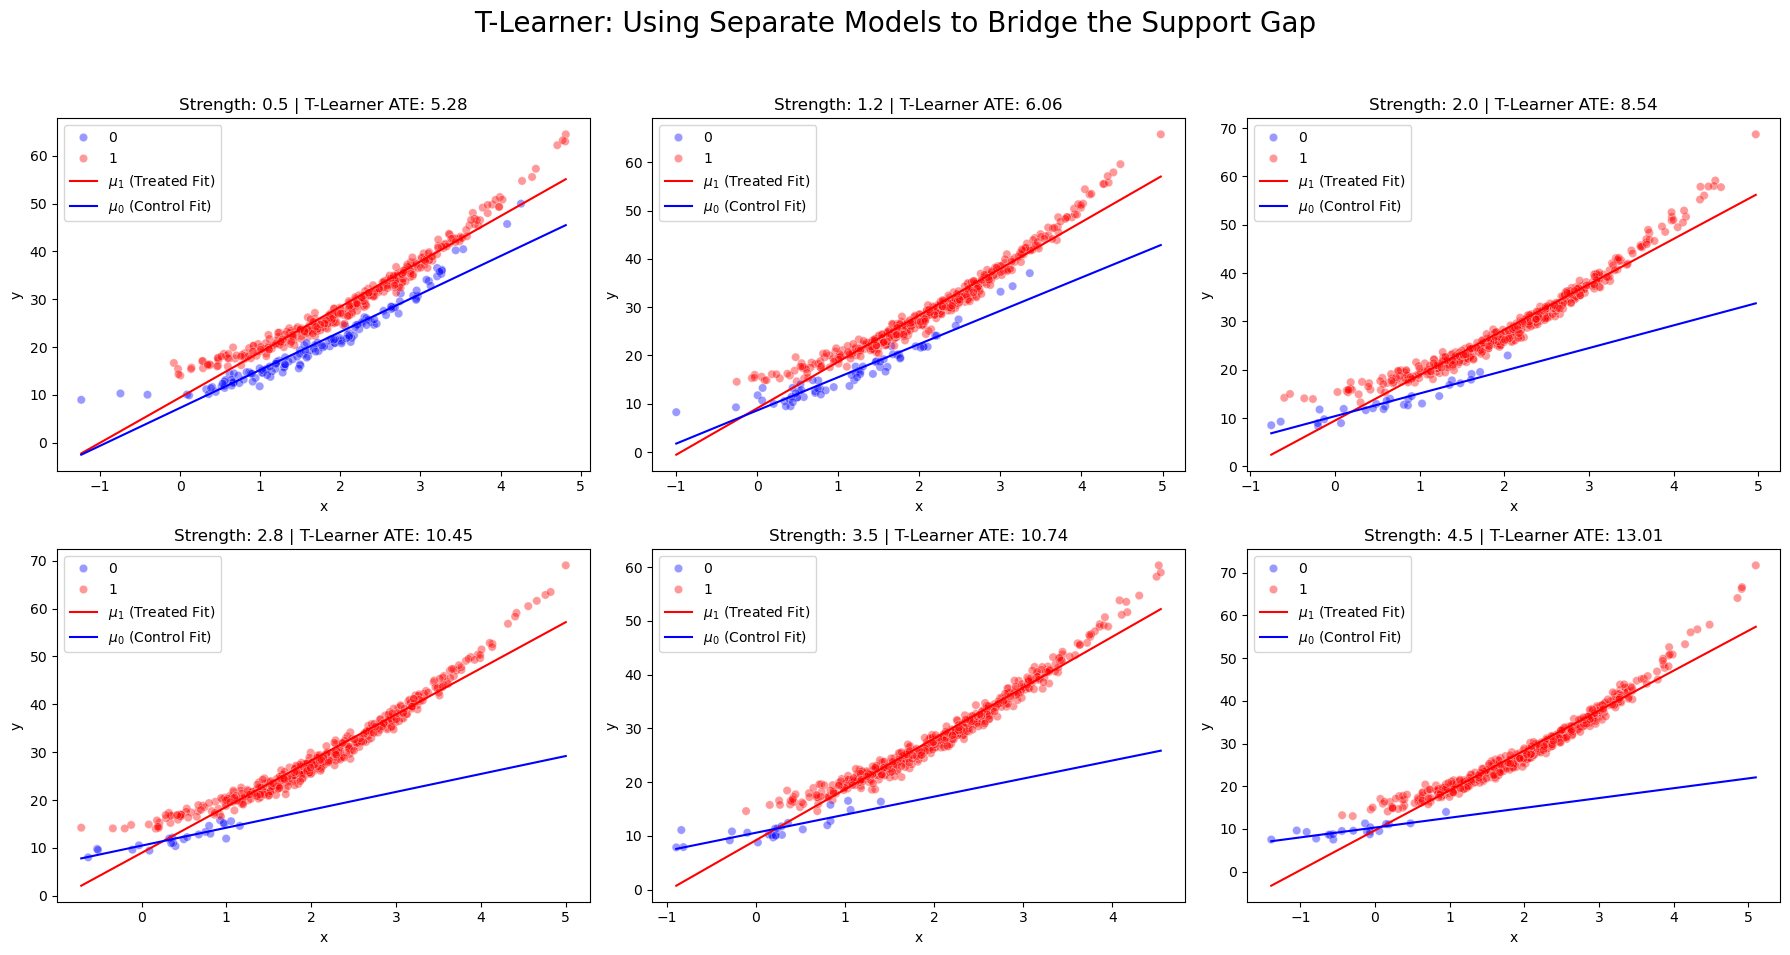

In [23]:
strengths = [0.5, 1.2, 2.0, 2.8, 3.5, 4.5]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    df = generate_research_data(n=500, overlap_strength=s)
    
    # T-Learner logic for the plot
    m1 = LinearRegression().fit(df[df.t==1][['x']], df[df.t==1]['y'])
    m0 = LinearRegression().fit(df[df.t==0][['x']], df[df.t==0]['y'])
    t_ate = (m1.predict(df[['x']]) - m0.predict(df[['x']])).mean()
    
    sns.scatterplot(data=df, x='x', y='y', hue='t', ax=axes[i], palette=['blue', 'red'], alpha=0.4)
    
    # Plotting the two separate T-Learner lines
    x_range = np.linspace(df.x.min(), df.x.max(), 100).reshape(-1, 1)
    axes[i].plot(x_range, m1.predict(x_range), color='red', label='$\mu_1$ (Treated Fit)')
    axes[i].plot(x_range, m0.predict(x_range), color='blue', label='$\mu_0$ (Control Fit)')
    
    axes[i].set_title(f"Strength: {s} | T-Learner ATE: {t_ate:.2f}")
    axes[i].legend()

plt.suptitle("T-Learner: Using Separate Models to Bridge the Support Gap", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

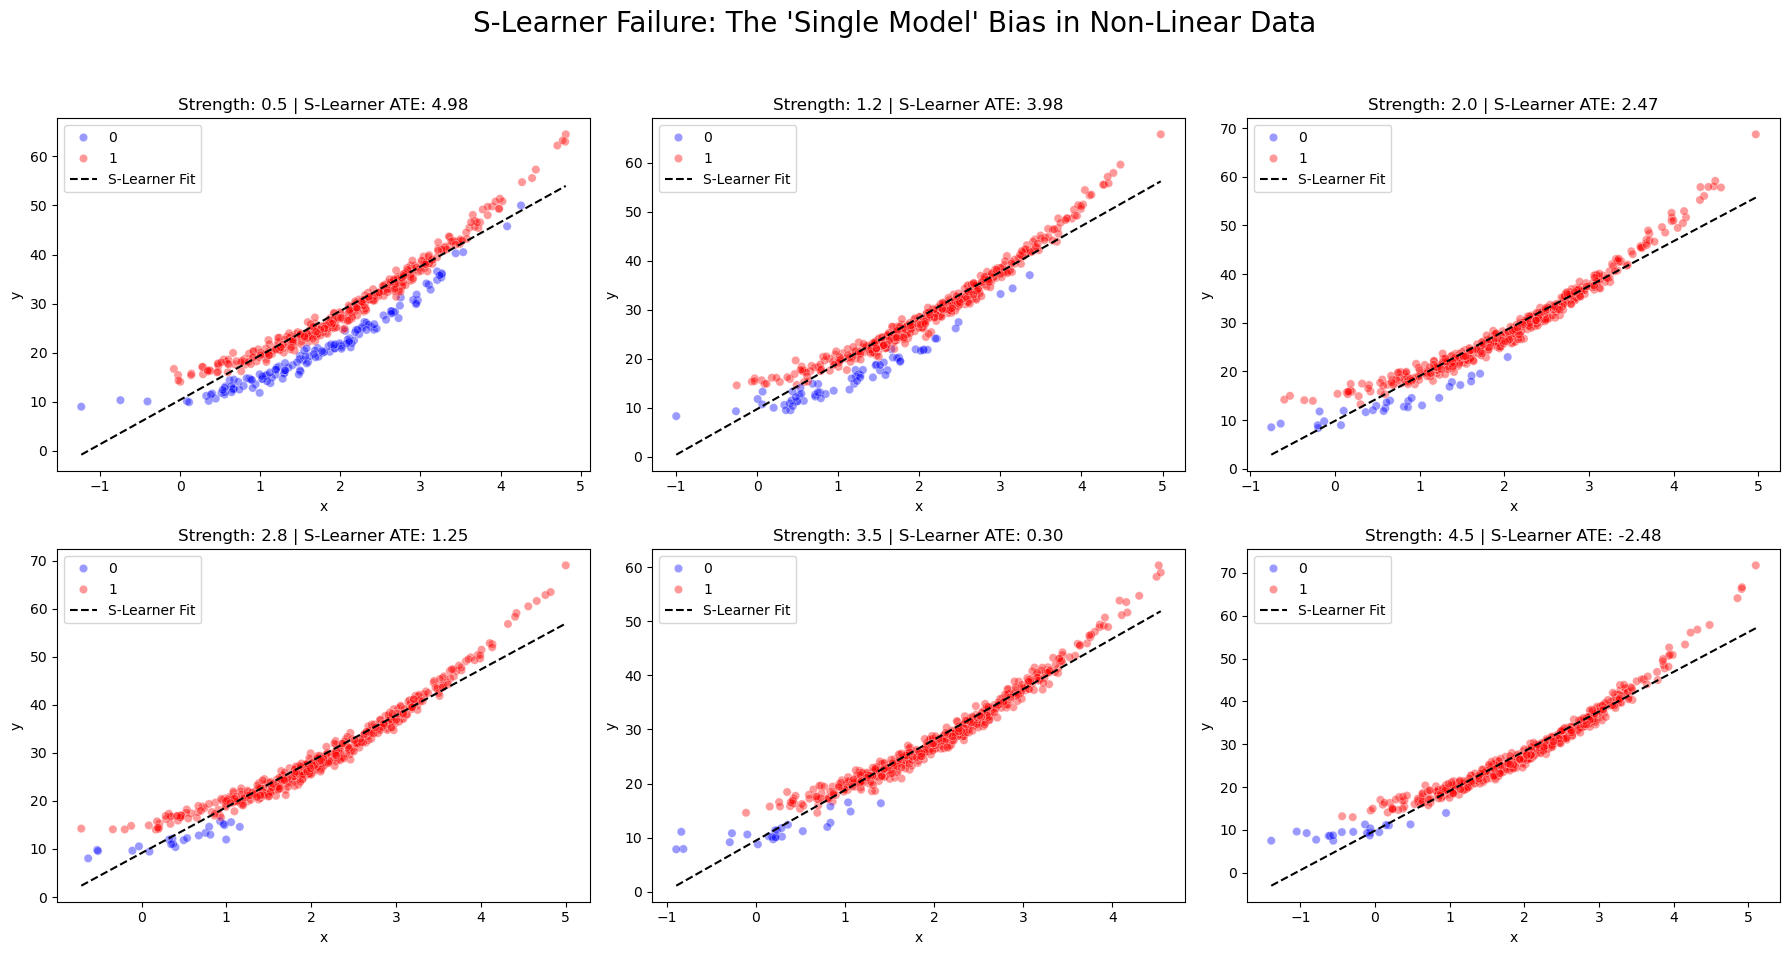

In [24]:
strengths = [0.5, 1.2, 2.0, 2.8, 3.5, 4.5]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    # Generate data
    df = generate_research_data(n=500, overlap_strength=s)
    
    # S-Learner Estimation
    # Model: y = b0 + b1*t + b2*x
    s_mod = LinearRegression().fit(df[['t', 'x']], df['y'])
    
    # Calculate ATE: Difference in predictions for everyone (T=1 vs T=0)
    df_t1 = df.copy(); df_t1['t'] = 1
    df_t0 = df.copy(); df_t0['t'] = 0
    s_ate = (s_mod.predict(df_t1[['t', 'x']]) - s_mod.predict(df_t0[['t', 'x']])).mean()
    
    # Visualization
    sns.scatterplot(data=df, x='x', y='y', hue='t', ax=axes[i], palette=['blue', 'red'], alpha=0.4)
    
    # Plot the "Single" surface fit
    x_vals = np.linspace(df.x.min(), df.x.max(), 100)
    # We plot the line for T=1 to show the slope the model chose
    axes[i].plot(x_vals, s_mod.predict(pd.DataFrame({'t': 1, 'x': x_vals})), 
                 color='black', linestyle='--', label='S-Learner Fit')
    
    axes[i].set_title(f"Strength: {s} | S-Learner ATE: {s_ate:.2f}")
    axes[i].legend()

plt.suptitle("S-Learner Failure: The 'Single Model' Bias in Non-Linear Data", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

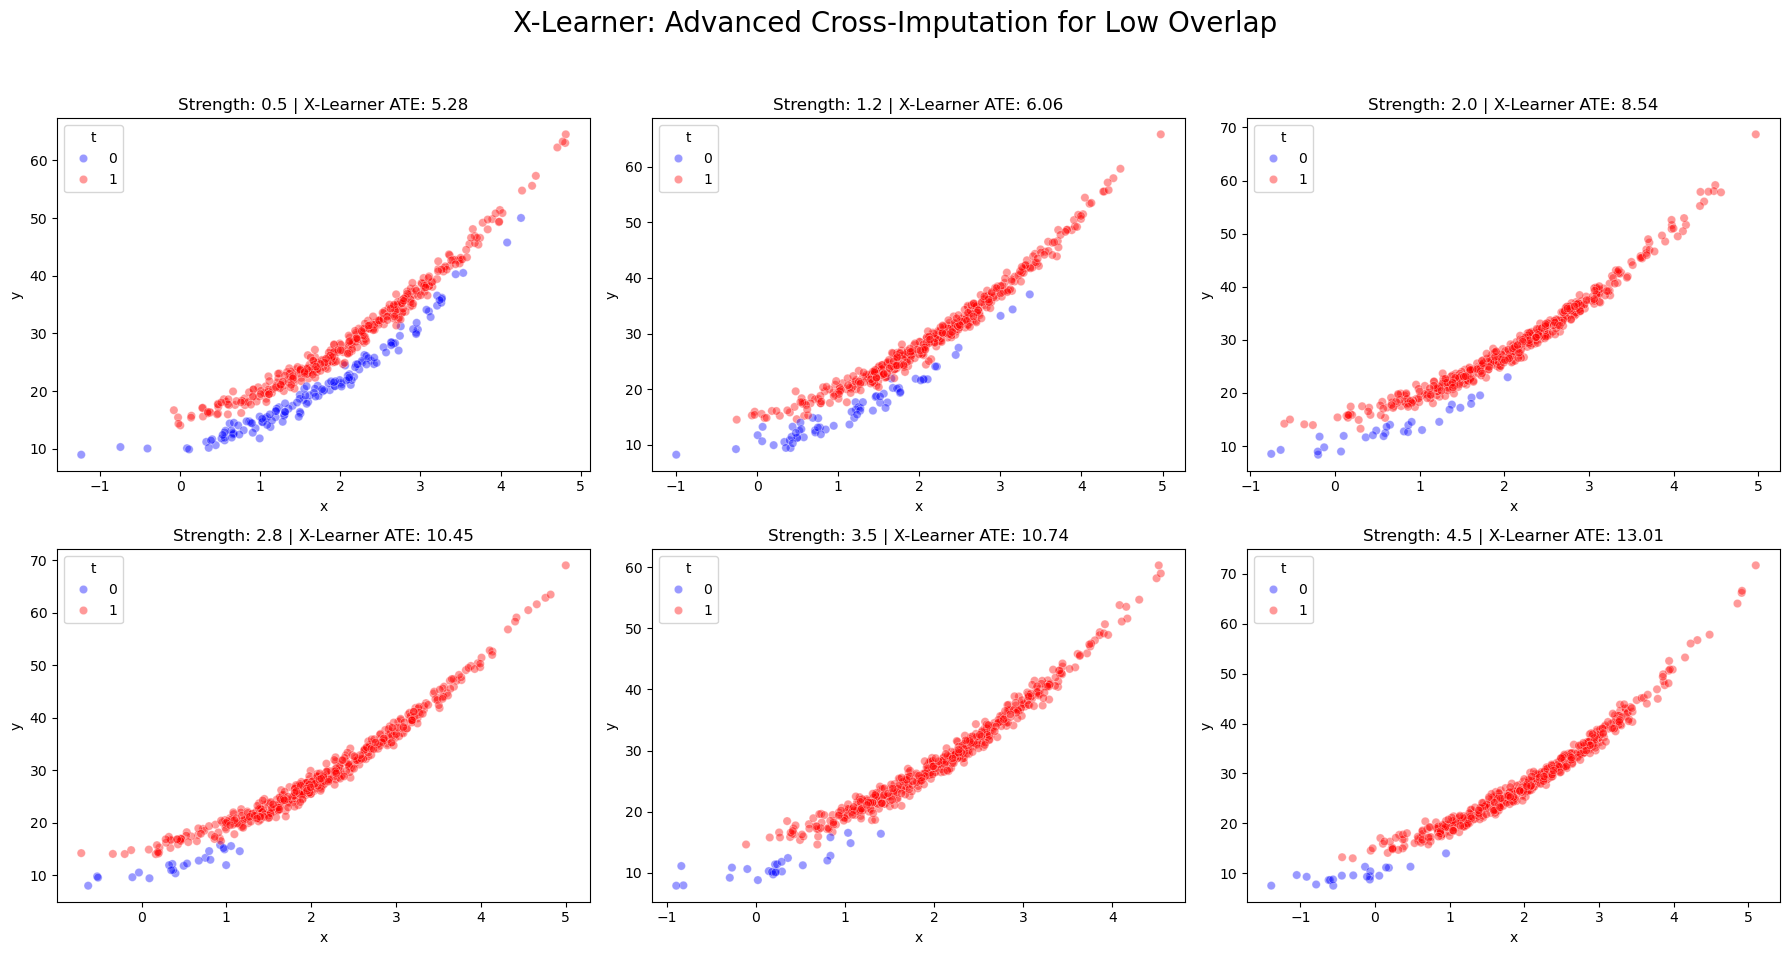

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, s in enumerate(strengths):
    df = generate_research_data(n=500, overlap_strength=s)
    
    # Calculate X-Learner ATE
    lr = LogisticRegression(penalty=None).fit(df[['x']], df['t'])
    ps = lr.predict_proba(df[['x']])[:, 1]
    m1 = LinearRegression().fit(df[df.t==1][['x']], df[df.t==1]['y'])
    m0 = LinearRegression().fit(df[df.t==0][['x']], df[df.t==0]['y'])
    d1 = df[df.t==1]['y'] - m0.predict(df[df.t==1][['x']])
    d0 = m1.predict(df[df.t==0][['x']]) - df[df.t==0]['y']
    mx1 = LinearRegression().fit(df[df.t==1][['x']], d1)
    mx0 = LinearRegression().fit(df[df.t==0][['x']], d0)
    x_ate = (ps * mx0.predict(df[['x']]) + (1 - ps) * mx1.predict(df[['x']])).mean()
    
    sns.scatterplot(data=df, x='x', y='y', hue='t', ax=axes[i], palette=['blue', 'red'], alpha=0.4)
    axes[i].set_title(f"Strength: {s} | X-Learner ATE: {x_ate:.2f}")

plt.suptitle("X-Learner: Advanced Cross-Imputation for Low Overlap", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

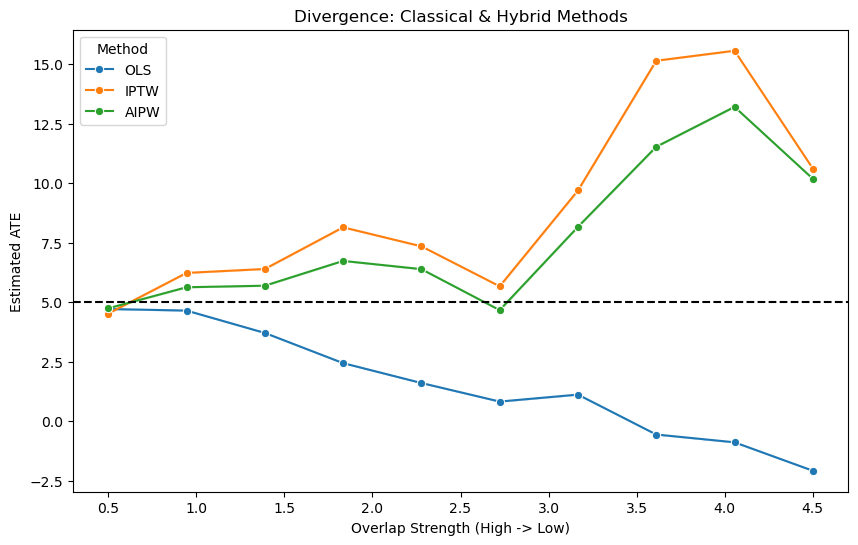

In [34]:
overlap_range = np.linspace(0.5, 4.5, 10)
results = []
for s in overlap_range:
    for _ in range(15):
        df = generate_research_data(overlap_strength=s)
        ests = get_all_estimates(df)
        for name, val in ests.items():
            results.append({'Strength': s, 'Method': name, 'ATE': val})

df_res = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_res[df_res.Method.isin(['OLS', 'IPTW', 'AIPW'])], x='Strength', y='ATE', hue='Method', marker='o', errorbar='sd')
plt.axhline(5.0, color='black', linestyle='--', label='True ATE')
plt.title("Divergence: Classical & Hybrid Methods")
plt.ylabel("Estimated ATE")
plt.xlabel("Overlap Strength (High -> Low)")
plt.show()

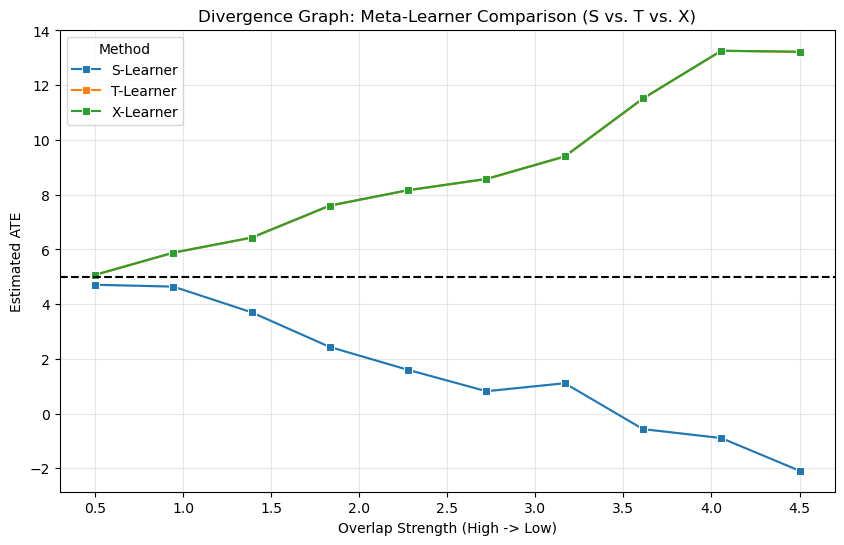

In [35]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_res[df_res.Method.isin(['S-Learner', 'T-Learner', 'X-Learner'])], x='Strength', y='ATE', hue='Method', marker='s', errorbar='sd')
plt.axhline(5.0, color='black', linestyle='--', label='True ATE (5.0)')
plt.title("Divergence Graph: Meta-Learner Comparison (S vs. T vs. X)")
plt.ylabel("Estimated ATE")
plt.xlabel("Overlap Strength (High -> Low)")
plt.grid(True, alpha=0.3)
plt.show()